# Sampling of the Neal's funnel distribution

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox.cometric import  FunnelSoftAbs, FunnelDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [2]:
# --- Cyan→magenta chain-scatter aesthetic (same as the bump-metric notebook) ---
from matplotlib.colors import LinearSegmentedColormap

CHAIN_CMAP = LinearSegmentedColormap.from_list("cyan_magenta", ["#00e5ff", "#ff00d4"])


def scatter_funnel_chain(ax, traj, n_show=None, s=4, alpha=0.7):
    """Scatter funnel chains over the density background, coloured cyan→magenta
    along the chain index (time). Funnel layout: x = θ_1 (col 1), y = v (col 0).

    traj : tensor/array of shape (n_chains, n_steps, dim+1).
    """
    t = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
    n = t.shape[0] if n_show is None else min(n_show, t.shape[0])
    colors = CHAIN_CMAP(np.linspace(0, 1, t.shape[1]))
    for i in range(n):
        ax.scatter(t[i, :, 1], t[i, :, 0], c=colors, s=s, alpha=alpha,
                   edgecolors="none", zorder=3)
    # start points
    ax.scatter(t[:n, 0, 1], t[:n, 0, 0], facecolor="white", edgecolor="black",
               linewidth=0.6, s=30, zorder=4)

In this notebook we aim at benchmarking how our method, FHMC, performs on the sampling of Neal's funnel distribution : 

\begin{equation}
    \pi(\theta, v) = \mathcal N(v| 0,9)\prod_{i = 1}^K\mathcal N(\theta_i|0, e^v)  
\end{equation}

we can take $K = 10$ and $K = 30$ if it works well ...

## Riemannian Hamiltonian Monte Carlo Sampling

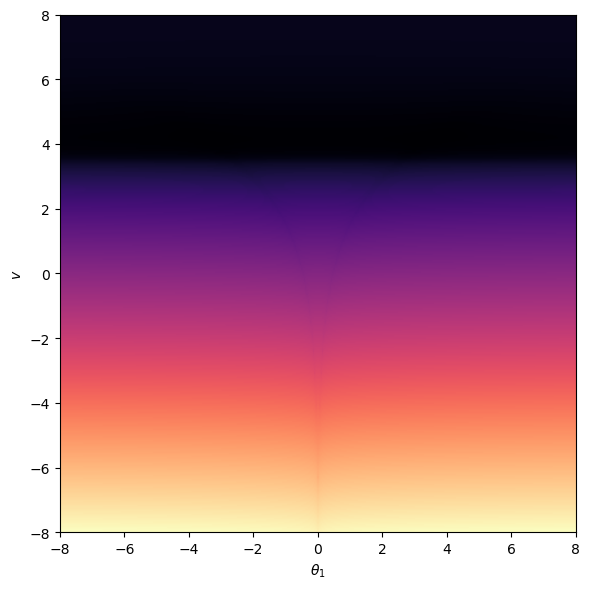

In [3]:
dim = 30

grid_fine = 400
t1g = np.linspace(-8, 8, grid_fine)   # θ_1-axis (x)
vg  = np.linspace(-8, 8, grid_fine)   # v-axis    (y)
tt, vv = np.meshgrid(t1g, vg)         # note: swapped order

N = grid_fine * grid_fine
zeros_rest = np.zeros((N, dim- 1), dtype=np.float32)

pts = torch.tensor(
    np.concatenate([
        vv.ravel()[:, None],
        tt.ravel()[:, None],
        zeros_rest,
    ], axis=1),
    dtype=torch.float32,
)

cometric = FunnelSoftAbs(dim, alpha=1e3)
with torch.no_grad():
    G = cometric.metric_tensor(pts)
    log_det_G = torch.linalg.slogdet(G).logabsdet.numpy().reshape(grid_fine, grid_fine)

# Marginal log-density of (v, θ_1): only one θ contributes the -v/2 term
log_pi = -vv**2 / 18 - 0.5 * vv - np.exp(-vv) / 2 * tt**2

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_det_G,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],  # x=θ_1, y=v
    cmap="magma",
    aspect="auto",
)


ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
plt.tight_layout()
plt.show()

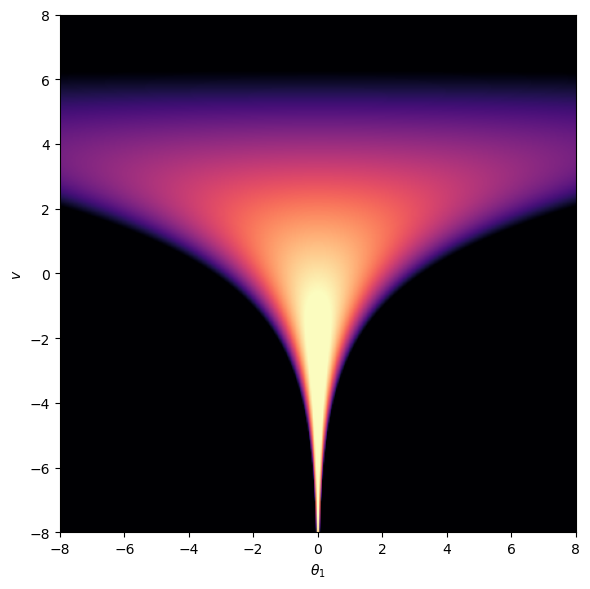

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

# Clip to the interesting central range, ignoring extreme tails
vmax = np.percentile(log_pi, 99)
vmin = np.percentile(log_pi, 60)   # adjust 60→50 or 70 to taste

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)


ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
plt.tight_layout()
plt.show()

### Definition of the sampler

In [5]:
class FunnelRHMC(ImplicitRHMCSampler):
    def __init__(self, dim: int, l: int, N_fx: int, gamma: float, N_run: int, std_0: float = 1, bounds: float = 1000, beta_0: float = 1, pbar: bool = False, skip_acceptance: bool = False, threshold_fx: float = 0.00001, alpha: float = 1.):
        self.dim = dim
        cometric = FunnelSoftAbs(dim=dim, alpha=alpha)
        super().__init__(cometric, l, N_fx, gamma, N_run, std_0, bounds, beta_0, pbar, skip_acceptance, threshold_fx)

    def U(self, z):
        v     = z[:, 0]          # (N,)
        theta = z[:, 1:]         # (N, K)
        return v**2 / 18 + (self.dim / 2) * v + torch.exp(-v) / 2 * (theta**2).sum(dim=1)

In [ ]:
dim = 30
l = 40
N_fx = 12
gamma = 0.05
N_run = 300

sampler = FunnelRHMC(
    dim, 
    l, 
    N_fx, 
    gamma, 
    N_run,
    pbar = True
)

### Sampling a trajectory

In [7]:
n_traj = 50
z_0 = torch.zeros(n_traj, dim + 1)
traj_rhmc, acc_rhmc = sampler.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True
    )
print(f"Acceptance rate: {acc_rhmc:.4f}")

Sampling:   0%|          | 0/300 [00:00<?, ?steps/s]

Sampling: 100%|██████████| 300/300 [02:17<00:00,  2.19steps/s, acceptance_rate=0.992]

Acceptance rate: 0.9925


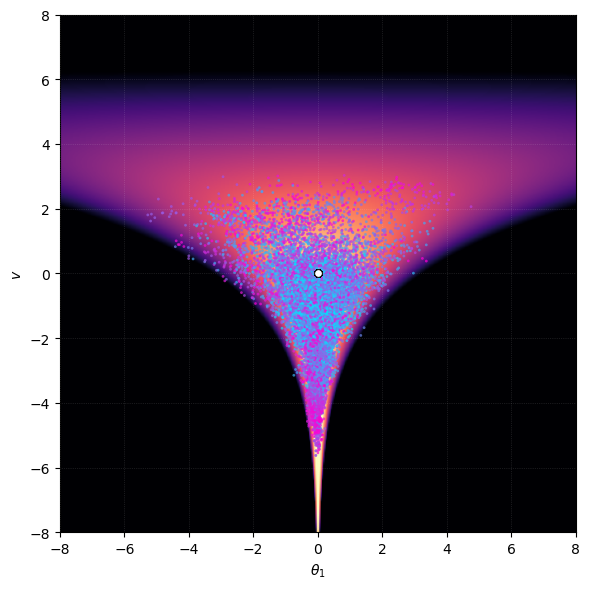

In [8]:
dim = 30

grid_fine = 400
t1g = np.linspace(-8, 8, grid_fine)   # θ_1-axis (x)
vg  = np.linspace(-8, 8, grid_fine)   # v-axis    (y)
tt, vv = np.meshgrid(t1g, vg)

# Marginal log-density of (v, θ_1): only one θ contributes the -v/2 term
log_pi = -vv**2 / 18 - 0.5 * vv - np.exp(-vv) / 2 * tt**2

vmax = np.percentile(log_pi, 99)
vmin = np.percentile(log_pi, 60)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    zorder=0,
)

# --- Chain scatter: cyan→magenta along the chain index ---
scatter_funnel_chain(ax, traj_rhmc)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
ax.set_xlim(t1g.min(), t1g.max())
ax.set_ylim(vg.min(), vg.max())
plt.tight_layout()
plt.show()

## Finsler Randers Hamiltonian Monte Carlo Sampling

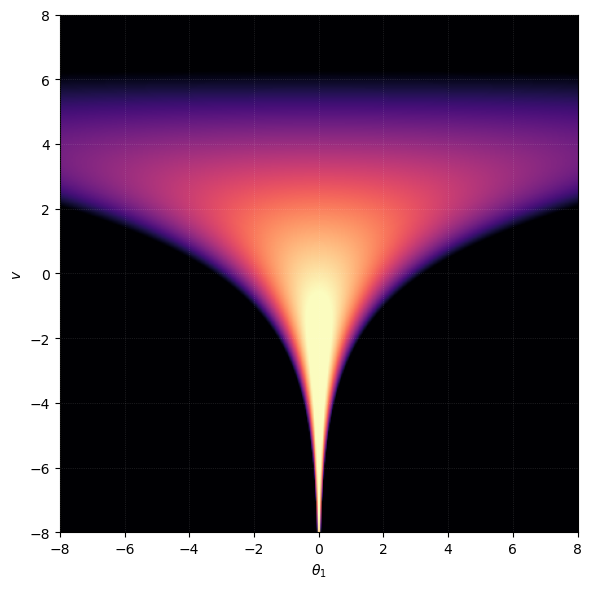

In [15]:
dim    = 30

grid_fine   = 400
grid_stream = 100

t1g = np.linspace(-8, 8, grid_fine)
vg  = np.linspace(-8, 8, grid_fine)
tt, vv = np.meshgrid(t1g, vg)

# Marginal log-density of (v, θ_1): only one θ contributes the -v/2 term
log_pi  = -vv**2 / 18 - 0.5 * vv - np.exp(-vv) / 2 * tt**2
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 60)

t1g_s = np.linspace(-8, 8, grid_stream)
vg_s  = np.linspace(-8, 8, grid_stream)
tt_s, vv_s = np.meshgrid(t1g_s, vg_s)

# Analytical marginal score of p(v, θ_1):
#   ∂log p / ∂v   = -v/9 - 0.5 + e^{-v}/2 * θ_1²
#   ∂log p / ∂θ_1 = -e^{-v} * θ_1
exp_mv  = np.exp(-vv_s)
V = -vv_s / 9.0 - 0.5 + 0.5 * exp_mv * tt_s**2
U = -exp_mv * tt_s

fig, ax = plt.subplots(figsize=(6, 6))

# Background: log-density
im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],
    cmap="magma",
    aspect="equal",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

# # Streamplot
# sp = ax.streamplot(
#     t1g_s, vg_s,
#     U, V,
#     color="white",
#     linewidth=0.4,
#     density=1.2,
#     arrowsize=0.5,
#     arrowstyle="->",
#     zorder=2,
# )
# sp.lines.set_alpha(0.25)
# sp.arrows.set_alpha(0.15)

# Dotted grid
ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
ax.set_xlim(t1g.min(), t1g.max())
ax.set_ylim(vg.min(), vg.max())
plt.tight_layout()
plt.show()

### Definition of the sampler

In [10]:
class FunnelFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, dim : int, l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True, alpha: float = 1., beta : float = 1.):
        self.dim = dim
        randers_cometric = FunnelDualRanders(dim = dim, alpha=alpha, beta = beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, z):
        v     = z[:, 0]          # (N,)
        theta = z[:, 1:]         # (N, K)
        return v**2 / 18 + (self.dim / 2) * v + torch.exp(-v) / 2 * (theta**2).sum(dim=1)
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)   # ONE eigh

        # F* without re-eigh
        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2     # avoid the throw-away outer sqrt

        # BH terms via one Cholesky of G* (G* is already in hand)
        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)


    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)

        L             = torch.linalg.cholesky(G_star)
        y             = torch.linalg.solve_triangular(
                            L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq          = torch.einsum("bi,bi->b", y, y)   
        alpha_s       = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)
        log_sigma_BH  = -0.5 * logdet_G_star

        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)  
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)          

        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )


### Unbiased sampler without reduced flips

In [11]:
dim = 30
l = 5
N_fx = 6
gamma = 0.12
N_run = 300
beta = 0.3

sampler_unbiased = FunnelFHMCUnbiased(
    dim = dim,
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta,
    reduced_flip = False
)

In [12]:
n_traj = 50
z_0 = torch.zeros(n_traj, dim + 1)   # shape (n_traj, 11)  ✓
traj_fhmc, acc_fhmc, flip_fhmc = sampler_unbiased.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc:.4f}")
print(f"Momentum flip rate: {flip_fhmc:.4f}")

Sampling: 100%|██████████| 300/300 [02:47<00:00,  1.79steps/s, acceptance_rate=0.622]

Acceptance rate: 0.6220
Momentum flip rate: 0.3780


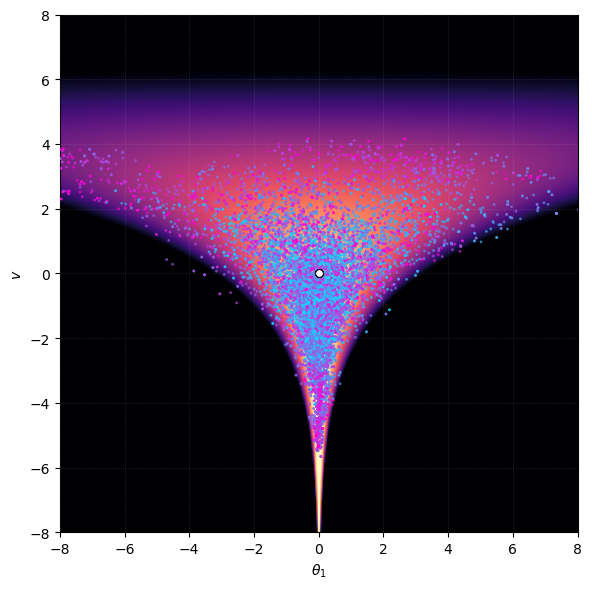

In [16]:
dim    = 30

grid_fine   = 400
grid_stream = 100

t1g = np.linspace(-8, 8, grid_fine)
vg  = np.linspace(-8, 8, grid_fine)
tt, vv = np.meshgrid(t1g, vg)

# Marginal log-density of (v, θ_1): only one θ contributes the -v/2 term
log_pi  = -vv**2 / 18 - 0.5 * vv - np.exp(-vv) / 2 * tt**2
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 60)

t1g_s = np.linspace(-8, 8, grid_stream)
vg_s  = np.linspace(-8, 8, grid_stream)
tt_s, vv_s = np.meshgrid(t1g_s, vg_s)

# Analytical marginal score of p(v, θ_1):
#   ∂log p / ∂v   = -v/9 - 0.5 + e^{-v}/2 * θ_1²
#   ∂log p / ∂θ_1 = -e^{-v} * θ_1
exp_mv  = np.exp(-vv_s)
V = -vv_s / 9.0 - 0.5 + 0.5 * exp_mv * tt_s**2
U = -exp_mv * tt_s

fig, ax = plt.subplots(figsize=(6, 6))

# Background: log-density
im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],
    cmap="magma",
    aspect="equal",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

# # Streamplot
# sp = ax.streamplot(
#     t1g_s, vg_s,
#     U, V,
#     color="white",
#     linewidth=0.4,
#     density=1.2,
#     arrowsize=0.5,
#     arrowstyle="->",
#     zorder=2,
# )
# sp.lines.set_alpha(0.25)
# sp.arrows.set_alpha(0.15)

# --- Chain scatter: cyan→magenta along the chain index ---
scatter_funnel_chain(ax, traj_fhmc)

# Dotted grid
ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
ax.set_xlim(t1g.min(), t1g.max())
ax.set_ylim(vg.min(), vg.max())
plt.tight_layout()
plt.show()

### Unbiased Sampler with reduced flip

In [14]:
dim = 30
l = 5
N_fx = 6
gamma = 0.12
N_run = 1000
beta = 0.2

sampler_unbiased_rf = FunnelFHMCUnbiased(
    dim = dim,
    l = l, 
    N_fx= N_fx, 
    gamma = gamma, 
    N_run = N_run, 
    beta = beta
)

In [15]:
n_traj = 50
z_0 = torch.zeros(n_traj, dim + 1)
traj_fhmc_rf, acc_fhmc_rf, flip_fhmc_rf = sampler_unbiased_rf.sample(
    z_0, 
    return_traj = True, 
    progress = True,
    return_acceptance= True,
    return_flip = True
    )
print(f"Acceptance rate: {acc_fhmc_rf:.4f}")
print(f"Momentum flip rate: {flip_fhmc_rf:.4f}")

Sampling: 100%|██████████| 1000/1000 [12:28<00:00,  1.34steps/s, acceptance_rate=0.73]

Acceptance rate: 0.7301
Momentum flip rate: 0.1800


In [ ]:
dim    = 30

grid_fine   = 400
grid_stream = 100

t1g = np.linspace(-8, 8, grid_fine)
vg  = np.linspace(-8, 8, grid_fine)
tt, vv = np.meshgrid(t1g, vg)

# Marginal log-density of (v, θ_1): only one θ contributes the -v/2 term
log_pi  = -vv**2 / 18 - 0.5 * vv - np.exp(-vv) / 2 * tt**2
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 60)

t1g_s = np.linspace(-8, 8, grid_stream)
vg_s  = np.linspace(-8, 8, grid_stream)
tt_s, vv_s = np.meshgrid(t1g_s, vg_s)

# Analytical marginal score of p(v, θ_1):
#   ∂log p / ∂v   = -v/9 - 0.5 + e^{-v}/2 * θ_1²
#   ∂log p / ∂θ_1 = -e^{-v} * θ_1
exp_mv  = np.exp(-vv_s)
V = -vv_s / 9.0 - 0.5 + 0.5 * exp_mv * tt_s**2
U = -exp_mv * tt_s

fig, ax = plt.subplots(figsize=(6, 6))

# Background: log-density
im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[t1g.min(), t1g.max(), vg.min(), vg.max()],
    cmap="magma",
    aspect="equal",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

# Streamplot
# sp = ax.streamplot(
#     t1g_s, vg_s,
#     U, V,
#     color="white",
#     linewidth=0.4,
#     density=1.2,
#     arrowsize=0.5,
#     arrowstyle="->",
#     zorder=2,
# )
# sp.lines.set_alpha(0.25)
# sp.arrows.set_alpha(0.15)

# --- Chain scatter: cyan→magenta along the chain index ---
scatter_funnel_chain(ax, traj_fhmc_rf)

# Dotted grid
ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$v$")
ax.set_xlim(t1g.min(), t1g.max())
ax.set_ylim(vg.min(), vg.max())
plt.tight_layout()
plt.show()

## Autocorrelation comparison

Sampler                         min ESS   worst dim
───────────────────────────────────────────────────────
RHMC                              388.6         $v$
FHMC (reduced flip)               514.4         $v$
FHMC (no reduced flip)            587.3         $v$


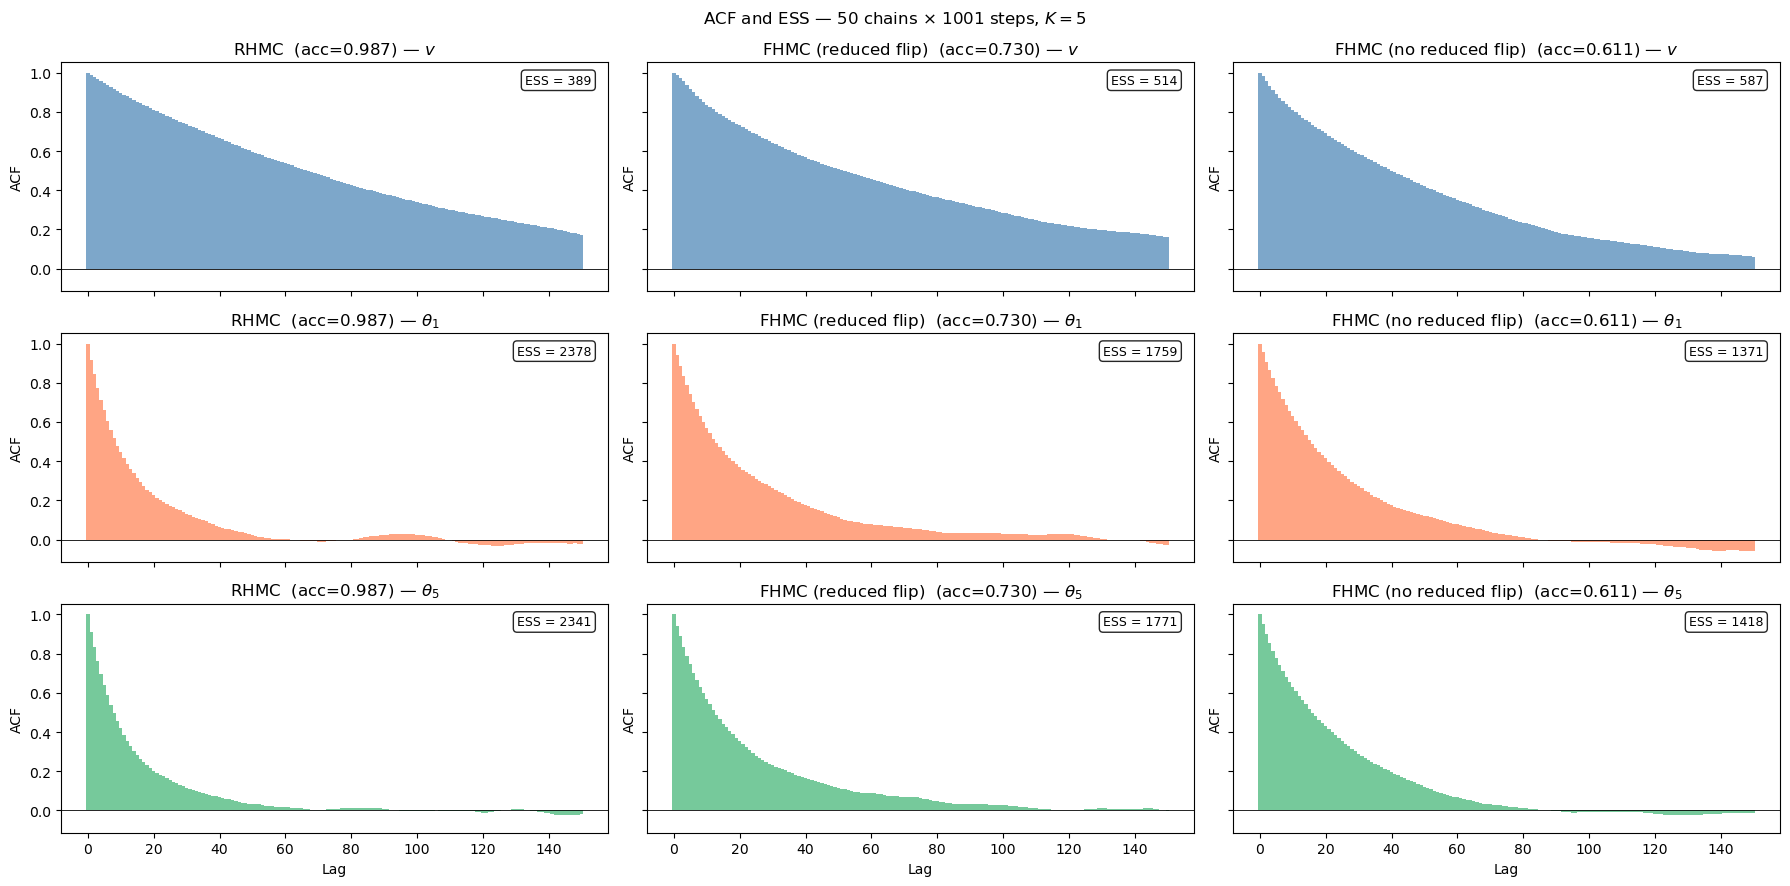

In [17]:
def acf(chain, max_lag):
    """Normalized autocorrelation at lags 0..max_lag for a 1D array."""
    chain = chain - chain.mean()
    var = np.var(chain)
    return np.array([
        np.mean(chain[:len(chain) - k] * chain[k:]) / var if k > 0 else 1.0
        for k in range(max_lag + 1)
    ])

def ess_from_chain(chain, max_lag):
    """
    ESS = N / IAT,  IAT = 1 + 2 * sum_{k>=1} ACF(k).
    Sum truncated at the first negative lag (Geyer's initial positive sequence).
    """
    ac = acf(chain, max_lag)
    first_neg = np.argmax(ac[1:] < 0)
    cutoff = first_neg if first_neg > 0 else max_lag
    iat = 1.0 + 2.0 * ac[1:cutoff + 1].sum()
    return len(chain) / max(iat, 1.0)

def mean_acf(traj, dim, max_lag):
    """Average ACF over all chains for a given coordinate dimension."""
    return np.mean([acf(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0])], axis=0)

def total_ess(traj, dim, max_lag):
    """Total ESS summed over all chains for a given coordinate dimension."""
    return sum(ess_from_chain(traj[i, :, dim].numpy(), max_lag) for i in range(traj.shape[0]))

def min_ess(traj, max_lag):
    """Min ESS across all K+1 dimensions, summed over chains."""
    return min(
        sum(ess_from_chain(traj[i, :, d].numpy(), max_lag) for i in range(traj.shape[0]))
        for d in range(traj.shape[2])
    )

def argmin_ess_dim(traj, max_lag):
    """Which dimension achieves the minimum ESS."""
    ess_per_dim = [
        sum(ess_from_chain(traj[i, :, d].numpy(), max_lag) for i in range(traj.shape[0]))
        for d in range(traj.shape[2])
    ]
    return int(np.argmin(ess_per_dim)), ess_per_dim

max_lag  = 150
lags     = np.arange(max_lag + 1)
n_chains = traj_rhmc.shape[0]
n_steps  = traj_rhmc.shape[1]

# ── ESS summary table ────────────────────────────────────────────────────────
print(f"{'Sampler':<28} {'min ESS':>10}  {'worst dim':>10}")
print("─" * 55)
for traj, label in [
    (traj_rhmc,    "RHMC"),
    (traj_fhmc_rf, "FHMC (reduced flip)"),
    (traj_fhmc,    "FHMC (no reduced flip)"),
]:
    worst_dim, ess_per_dim = argmin_ess_dim(traj, max_lag)
    dim_name = "$v$" if worst_dim == 0 else rf"$\theta_{{{worst_dim}}}$"
    print(f"{label:<28} {ess_per_dim[worst_dim]:10.1f}  {dim_name:>10}")

# ── ACF plots: show v, θ_1, θ_5 ──────────────────────────────────────────────
# dim 0 = v, dim 1 = θ_1, dim 5 = θ_5
plot_dims = [
    (r"$v$",         0, "steelblue"),
    (r"$\theta_1$",  1, "coral"),
    (r"$\theta_5$",  5, "mediumseagreen"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 9), sharey=True, sharex=True)

for row, (coord_name, dim, color) in enumerate(plot_dims):
    for col, (traj, acc, label) in enumerate([
        (traj_rhmc,    acc_rhmc,    "RHMC"),
        (traj_fhmc_rf, acc_fhmc_rf, "FHMC (reduced flip)"),
        (traj_fhmc,    acc_fhmc,    "FHMC (no reduced flip)"),
    ]):
        ac      = mean_acf(traj, dim, max_lag)
        ess_val = total_ess(traj, dim, max_lag)
        ax      = axes[row, col]
        ax.bar(lags, ac, width=1.0, color=color, alpha=0.7)
        ax.axhline(0, color="k", linewidth=0.6)
        ax.set_title(f"{label}  (acc={acc:.3f}) — {coord_name}")
        ax.set_ylabel("ACF")
        ax.text(0.97, 0.95, f"ESS = {ess_val:.0f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

for ax in axes[2]:
    ax.set_xlabel("Lag")

plt.suptitle(
    rf"ACF and ESS — {n_chains} chains × {n_steps} steps, $K={dim}$",
    fontsize=12,
)
plt.tight_layout()
plt.show()